In [1]:
import pyarrow
import math
from glob import glob
from BetaGLM import *
from GammaGLM import *
from GLMCollection import *

# Preprocessing of the features and metadata to format the dataframes

The GLMCollection assumes we are looking at overall proportions, parent/child proportions, densities, and spatial correlation dataframes with columns following specific naming conventions. These assumptions are used in the `get_celltype_annot_region_feature_type()` function in `statsmodels_utils.py` and the `add_model()` function in the `GLMCollection` class. **If your features are named differently you will have to change these functions**


### Conventions:

`cell_category` = broad category of cell labels, e.g. primary_celltype, secondary_celltype, tertiary_celltype, niche

`celltype` = specific value from cell_category, e.g. Myeloid from primary_celltypes, fibroblast from secondary_celltype

`region` = Integer value from annotated region. For the HPV project we only have two values: 2 = Stromal, 3 = Epithelial

* Proportion conventions
   * Column containing actual proportions saved as `{cell_category}_proportion_per_annot_region_{region}___{celltype}`
   * Column containing counts of given celltype saved as `{cell_category}_counts_per_annot_region_{region}___{celltype}`
   * Column containing total number of cells saved as `total_counts_per_annot_region_{region}`
* Parent/child proportions (eg secondary celltype per primary type, such as B_cells per B_plasma cells)
   * Column containing actual proportions saved as `{child_cell_category}_celltype_proportion_per_{parent_celltype}_per_annot_region_{region}___{child_celltype}`
   * Column containing count of child celltype saved as `{child_cell_category}_celltype_counts_per_annot_region_{region}___{child_celltype}`
   * Column containing count of parent celltype saved as `{parent_cell_category}_celltype_counts_per_annot_region_{region}___{parent_celltype}`
* Densities
   * Column containing densities saved as `{cell_category}_density_per_annot_region_{region}___{celltype}`
   * Column containing counts of given celltype saved as `{cell_category}_counts_per_annot_region_{region}___{celltype}`
   * Column containing area of given region saved as `annot{region}_area`
* Spatial Correlations
    * Column containing spatial correlation (w+1) saved as `{cell_category}_spatial_correlation_central_cell_{central_celltype}_radius_{radius_in_microns}_annot_region_{region}___{surrounding_celltype}`
    * Column containing number of expected cells saved as `{cell_category}_expected_count_central_cell_{central_celltype}_radius_{radius_in_microns}_annot_region_{region}___{surrounding_celltype}`
    * Column containing number of observed cells saved as `{cell_category}_observed_count_central_cell_{central_celltype}_radius_{radius_in_microns}_annot_region_{region}___{surrounding_celltype}`
* Codetection / Covering Fraction
   * Columns containing covering fraction saved as `{cell_category}_covering_fraction_{celltype_1}_radius_{radius}_annot_region_{region}___{celltype_2}`
   * Columns containing number of pixels from overlapping cell types saved as `{cell_category}_n_pixels_{celltype_1}_radius_{radius}_annot_region_{region}___{celltype_2}`
   * Columns containing total pixels for the area saved as `{cell_category}_total_pixels_{celltype_1}_radius_{radius}_annot_region_{region}___{celltype_2}`

These features also have columns calculated for the entire core (not per region) but I don't use them for anything

Read in the metadata

In [2]:
metadata = pd.read_csv('/common/knottsilab/xenium/hpv/metadata.csv', index_col = 0)
metadata.head(5)

,Unique TMA sample ID,TMA Block ID,TMA Block Name,Donor Block ID,Donor Block Images,Donor Core Height,core_idx,slide_idx,slide,batch,...,MRN,Accession_number,TMA,TMA_position,HPV_7,LR_HPV,No_SIL,LSIL,HSIL,Core_index
0,2.0,RB_1,AnoGen TMA #1,S14-24203,AnoGen TMAs_Images\BlockImages\AnoGen_SCC_TMAs...,4.16 mm,2.0,ag_hpv_01,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.0,RB_1,AnoGen TMA #1,S03-20099,AnoGen TMAs_Images\BlockImages\AnoGen_SCC_TMAs...,2.715 mm,3.0,ag_hpv_01,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,RB_1,AnoGen TMA #1,S18-00031,AnoGen TMAs_Images\BlockImages\AnoGen_SCC_TMAs...,3.997 mm,4.0,ag_hpv_01,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.0,RB_1,AnoGen TMA #1,S20-54703,AnoGen TMAs_Images\BlockImages\AnoGen_SCC_TMAs...,3.799 mm,5.0,ag_hpv_01,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6.0,RB_1,AnoGen TMA #1,S14-24203,AnoGen TMAs_Images\BlockImages\AnoGen_SCC_TMAs...,4.16 mm,6.0,ag_hpv_01,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,20250213__202616__X206_02132025_ANOGENTMA_1_2/...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Read in the features and areas

In [3]:
prop_densities = pd.read_csv('/common/lamt2/HPV/data/features/features_08_18_25/prop_densities.csv', index_col = 0)
prop_densities.head(5)

,primary_celltype_proportion___B_plasma,primary_celltype_proportion___Epithelial,primary_celltype_proportion___Mast_cell,primary_celltype_proportion___Myeloid,primary_celltype_proportion___NOS,primary_celltype_proportion___Stromal,primary_celltype_proportion___TNK,primary_celltype_proportion___muscle,primary_celltype_proportion___neural,secondary_celltype_proportion___B_cell,...,niche_cellcharter_counts_per_annot_region_2___27,niche_cellcharter_counts_per_annot_region_3___27,niche_cellcharter_counts_per_annot_region_2___28,niche_cellcharter_counts_per_annot_region_3___28,niche_cellcharter_counts_per_annot_region_2___29,niche_cellcharter_counts_per_annot_region_3___29,niche_cellcharter_counts_per_annot_region_2___30,niche_cellcharter_counts_per_annot_region_3___30,total_counts_per_annot_region_2,total_counts_per_annot_region_3
batch,,,,,,,,,,,,,,,,,,,,,
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___1,0.001053,0.587172,0.000124,0.029470,0.314636,0.060674,0.006872,0.0,0.000000,0.000310,...,0,0,0,0,0,0,4566,3,5622,10530
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___2,0.017634,0.233117,0.008004,0.113307,0.077539,0.380690,0.169460,0.0,0.000250,0.002626,...,235,0,0,0,0,0,45,0,6594,1402
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___5,0.002042,0.612658,0.005011,0.063289,0.098738,0.211210,0.007053,0.0,0.000000,0.000000,...,0,0,0,0,0,0,3,0,1913,3475
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___6,0.028130,0.500080,0.002993,0.060969,0.092850,0.215226,0.098635,0.0,0.001117,0.005945,...,2721,67,0,0,0,0,47,0,8111,16951
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___7,0.125209,0.329834,0.002860,0.081948,0.274358,0.116181,0.069570,0.0,0.000041,0.031496,...,1003,44,0,0,676,3199,764,2,16052,8427


In [4]:
areas = pd.read_csv('/common/lamt2/HPV/data/features/features_08_18_25/areas_df.csv', index_col = 0)
areas = areas.drop(['slide', 'core_idx'], axis = 1)

# Convert areas from um^2 to mm^2
areas['core_area'] = areas['core_area'] / (1000**2)
areas['annot2_area'] = areas['annot2_area'] / (1000**2)
areas['annot3_area'] = areas['annot3_area'] / (1000**2)

prop_densities = pd.merge(prop_densities, areas, left_index = True, right_index = True, how = 'left')
areas.head(2)

,core_area,annot2_area,annot3_area
batch,,,
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___1,1.774351,0.472998,1.301354
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___2,2.068467,1.890445,0.178023


Read in spatial correlations (and do a lot of reformatting)

In [5]:
spatial_dfs = {}
for feat in ['primary_celltype']: # Only read in primary celltype for this example
    spatial_dfs[feat] = {}
    spatial_files = glob(f'/common/lamt2/HPV/data/features/features_08_18_25/spatial_correlation*{feat}*.gzip')
    for f in tqdm(spatial_files, desc = f'Reading spatial correlations for {feat}'):
        name = f.split('/')[-1].split('.gzip')[0]
        spatial_dfs[feat][name] = pd.read_parquet(f)

merged_spatial_dfs = {}
for feat in ['primary_celltype']:
    merged_spatial_dfs[feat] = pd.DataFrame()
    for name in spatial_dfs[feat]:
        spatial_dfs[feat][name] = spatial_dfs[feat][name][spatial_dfs[feat][name]['region_1'] == spatial_dfs[feat][name]['region_2']]
        spatial_dfs[feat][name]['spatial_correlation'] = spatial_dfs[feat][name]['corr_coefficient'] + 1
        spatial_dfs[feat][name]['expected_count'] = spatial_dfs[feat][name]['permutation_counts'].apply(lambda x: x.mean())
        spatial_dfs[feat][name]['feature'] = spatial_dfs[feat][name].apply(lambda x: f'{feat}_spatial_correlation_central_cell_{x[f"{feat}_1"]}_radius_{x["radius"]}_annot_region_{x["region_1"]}___{x[f"{feat}_2"]}', axis = 1)
        pivot = spatial_dfs[feat][name].pivot(index = 'spatial_key', columns = 'feature', values = ['spatial_correlation', 'observed_count', 'expected_count'])
        pivot.columns = [f"{c[1].replace('spatial_correlation', c[0])}" for c in pivot.columns]
        merged_spatial_dfs[feat] = pd.concat([merged_spatial_dfs[feat], pivot], axis = 0, join = 'outer')
spatial_dfs_all = pd.concat([df for df in merged_spatial_dfs.values()], axis= 1, join = 'outer')

spatial_dfs_all.head(5)

Reading spatial correlations for primary_celltype: 100%|██████████| 10/10 [00:13<00:00,  1.33s/it]


,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___B_plasma,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___Epithelial,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___Mast_cell,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___Myeloid,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___NOS,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___Stromal,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___TNK,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___muscle,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_2___neural,primary_celltype_spatial_correlation_central_cell_B_plasma_radius_100_annot_region_3___B_plasma,...,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_2___neural,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___B_plasma,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___Epithelial,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___Mast_cell,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___Myeloid,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___NOS,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___Stromal,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___TNK,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___muscle,primary_celltype_expected_count_central_cell_neural_radius_50_annot_region_3___neural
spatial_key,,,,,,,,,,,,,,,,,,,,,
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060077__Region_1__20250213__202651___1,4.704856,0.094688,1.272400,0.967349,0.740675,0.675078,1.250433,NaN,0.295281,0.854792,...,0.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060077__Region_1__20250213__202651___10,6.014972,0.041562,1.989866,1.624610,1.018536,0.963748,1.895500,NaN,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060077__Region_1__20250213__202651___12,4.197317,0.081384,3.154308,3.123361,1.517362,2.573593,3.643024,NaN,NaN,1.488710,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060077__Region_1__20250213__202651___13,6.510200,0.014229,2.919811,3.054394,2.232780,3.621723,3.827747,NaN,NaN,4.436966,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060077__Region_1__20250213__202651___14,2.263269,0.042014,0.837876,1.107257,0.850157,1.106877,1.055974,NaN,0.551788,0.108967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Read in covering fractions and do a lot of formatting.

The covering fractions are symmetric between cell 1 and cell 2 (unlike spatial correlations), but I want both in the feature dataframe so we can FDR correct all codetections containing a specific cell more easily since the covering fraction feature_type is grouped by cell type 1

In [6]:
codetection = pd.read_csv('/common/lamt2/HPV/data/features/features_08_18_25/pairwise_covering_fraction.csv', index_col = 0)
codetection = codetection[codetection['region'] > 0].copy()
codetection = codetection[codetection['column'] == 'primary_celltype']
pivot1 = codetection.pivot(index = 'batch', columns = ['column', 'region', 'category1', 'category2', 'radius'], values = ['covering_fraction', 'n_pixels', 'total_pixels'])
col_names = [f'{c[1]}_{c[0]}_{c[3]}_radius_{c[5]}_annot_region_{c[2]}___{c[4]}' for c in pivot1.columns]
col_names_2 = [f'{c[1]}_{c[0]}_{c[4]}_radius_{c[5]}_annot_region_{c[2]}___{c[3]}' for c in pivot1.columns]

pivot1.columns = col_names
pivot2 = pivot1.copy()
pivot2.columns = col_names_2
codetection_df = pd.concat([pivot1, pivot2], axis = 1)

codetection_df.head(5)

,primary_celltype_covering_fraction_Epithelial_radius_5_annot_region_2___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_10_annot_region_2___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_20_annot_region_2___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_50_annot_region_2___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_5_annot_region_3___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_10_annot_region_3___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_20_annot_region_3___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_50_annot_region_3___Myeloid,primary_celltype_covering_fraction_Epithelial_radius_5_annot_region_2___TNK,primary_celltype_covering_fraction_Epithelial_radius_10_annot_region_2___TNK,...,primary_celltype_total_pixels_muscle_radius_20_annot_region_3___TNK,primary_celltype_total_pixels_muscle_radius_50_annot_region_3___TNK,primary_celltype_total_pixels_muscle_radius_5_annot_region_3___Mast_cell,primary_celltype_total_pixels_muscle_radius_10_annot_region_3___Mast_cell,primary_celltype_total_pixels_muscle_radius_20_annot_region_3___Mast_cell,primary_celltype_total_pixels_muscle_radius_50_annot_region_3___Mast_cell,primary_celltype_total_pixels_muscle_radius_5_annot_region_3___B_plasma,primary_celltype_total_pixels_muscle_radius_10_annot_region_3___B_plasma,primary_celltype_total_pixels_muscle_radius_20_annot_region_3___B_plasma,primary_celltype_total_pixels_muscle_radius_50_annot_region_3___B_plasma
batch,,,,,,,,,,,,,,,,,,,,,
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___1,0.000588,0.010331,0.056715,0.275473,0.002740,0.047174,0.183814,0.612352,0.000263,0.003431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___10,0.000756,0.026944,0.180187,0.654159,0.003371,0.073270,0.299066,0.860654,0.000101,0.003055,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___12,0.000222,0.010237,0.142894,0.746860,0.000087,0.004521,0.044330,0.261704,0.000157,0.004482,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___14,0.001283,0.026541,0.137466,0.415244,0.001875,0.048574,0.243201,0.754060,0.001451,0.027229,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___15,0.000025,0.000577,0.004941,0.049687,NaN,NaN,NaN,NaN,0.000008,0.000304,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Merge the features and metadata. Your final features dataframe should be indexed by core and have columns corresponding to the metadata and features

In [7]:
features_df = pd.merge(prop_densities, spatial_dfs_all, left_index = True, right_index = True, how = 'outer')
features_df = pd.merge(features_df, codetection_df, left_index = True, right_index = True, how = 'outer')
features_df = pd.merge(features_df, metadata, left_index = True, right_on = 'batch', how = 'left')
features_df.index = prop_densities.index

features_df.head(5)

,primary_celltype_proportion___B_plasma,primary_celltype_proportion___Epithelial,primary_celltype_proportion___Mast_cell,primary_celltype_proportion___Myeloid,primary_celltype_proportion___NOS,primary_celltype_proportion___Stromal,primary_celltype_proportion___TNK,primary_celltype_proportion___muscle,primary_celltype_proportion___neural,secondary_celltype_proportion___B_cell,...,MRN,Accession_number,TMA,TMA_position,HPV_7,LR_HPV,No_SIL,LSIL,HSIL,Core_index
batch,,,,,,,,,,,,,,,,,,,,,
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___1,0.001053,0.587172,0.000124,0.029470,0.314636,0.060674,0.006872,0.000000,0.000000,0.000310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___2,0.000198,0.444433,0.000346,0.061938,0.414452,0.070137,0.008496,0.000000,0.000000,0.000049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___5,0.032517,0.540696,0.021315,0.072370,0.081293,0.227521,0.021414,0.000099,0.002776,0.000198,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___6,0.008757,0.741144,0.002162,0.035136,0.067498,0.106743,0.038524,0.000000,0.000036,0.000360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20250213__202616__X206_02132025_ANOGENTMA_1_2/output-XETG00206__0060075__Region_1__20250213__202651___7,0.002538,0.022843,0.002538,0.038917,0.562606,0.334179,0.036379,0.000000,0.000000,0.000846,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Now we make the GLMCollection class that stores all of the regression models, then we fit and do permutation tests

First we setup the comparison we want to make:

We are interested in comparing diagnosis stage (no_sil, lsil, hsil, invasive) for squamous cell, p53-, HPV- patients

In [8]:
# col:val pairs for preselection. All patients used in the comparison must match this criteria
preselection = {
    'SCC_ADENO': 'SCC',
    'P53': 0,
    'HR_HPV': 0
}

# Key(s) for pseudobulking. We are pseudobulking per patient
group_key = ['Accession_no']

# Columns we are using for our predictors: we want to see differences in diagnosis stages
comparisons = ['Diagnosis']

In [9]:
# A quick filtering of our dataset to trim very low stats categories:
sub_feature_df = features_df[features_df['Diagnosis'] != 'SIL_ungraded'].copy()

# Make the glmcollection
glms = GLMCollection(sub_feature_df, preselection, group_key, comparisons)

Add primary celltype/niche proportions and densities and primary celltype spatial correlations to the model. Ordinarily we add everything but for this example we're only using these

In [10]:
# List of celltype comparisons to skip
skip = defaultdict(list)
skip['primary_celltype'] = ['NOS', 'muscle', 'neural'] # Skip primary celltypes with too limited statistics for comparisons
skip['secondary_celltype'] = ['NOS', 'muscle', 'Mast_cell', 'neural'] # Skip when primary celltype only has 1 secondary celltype
skip['tertiary_celltype'] = ['NOS', 'muscle', 'Mast_cell', 'neural', 'Epithelial', 'Epithelial_glandular', 'Epithelial_mixed', 'Epithelium_neuroendocrine', 'NK_gdT', 'pDC'] # Skip when secondary celltype only has 1 tertiary celltype

cols_to_add = [c for c in sub_feature_df.columns if 'primary_celltype_proportion_per_annot_region' in c or 'niche_cellcharter_proportion_per_annot_region' in c or 'primary_celltype_density_per_annot_region' in c or 'niche_cellcharter_density_per_annot_region' in c or 'primary_celltype_spatial_correlation' in c]

glms.add_models_batch(cols_to_add, skip = skip, verbose = True)

Creating Models from Batch: 100%|██████████| 808/808 [00:05<00:00, 142.28it/s]


Fit the models and the null models

In [11]:
glms.fit_models_parallel(verbose = False)
glms.fit_null_models_parallel(verbose = False)

Fitting null models: 100%|██████████| 604/604 [00:00<00:00, 1247.78it/s]


In [12]:
# for an example of the fit outputs:
print(glms.results['primary_celltype_proportion_per_annot_region_3___Epithelial'].summary())

                               BetaGLM Results                                
Dep. Variable:                   rate   Log-Likelihood:                 91.666
Model:                        BetaGLM   AIC:                            -173.3
Method:            Maximum Likelihood   BIC:                            -157.9
Date:                Fri, 07 Nov 2025                                         
Time:                        13:09:08                                         
No. Observations:                 161                                         
Df Residuals:                     156                                         
Df Model:                           3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.9209      0.234      3.928      0.000       0.461       1.380
Diagnosis[T.Invasiv

Use `GLMCollection.plot_model()` to display the distributions for each category:

Top plot = Normalized histograms for each category (optional overlaid with best fit distribution)

Bottom plot = Strip plot for each category (if fitted, use an envelope of the best fit distribution. Otherwise use a violin plot)

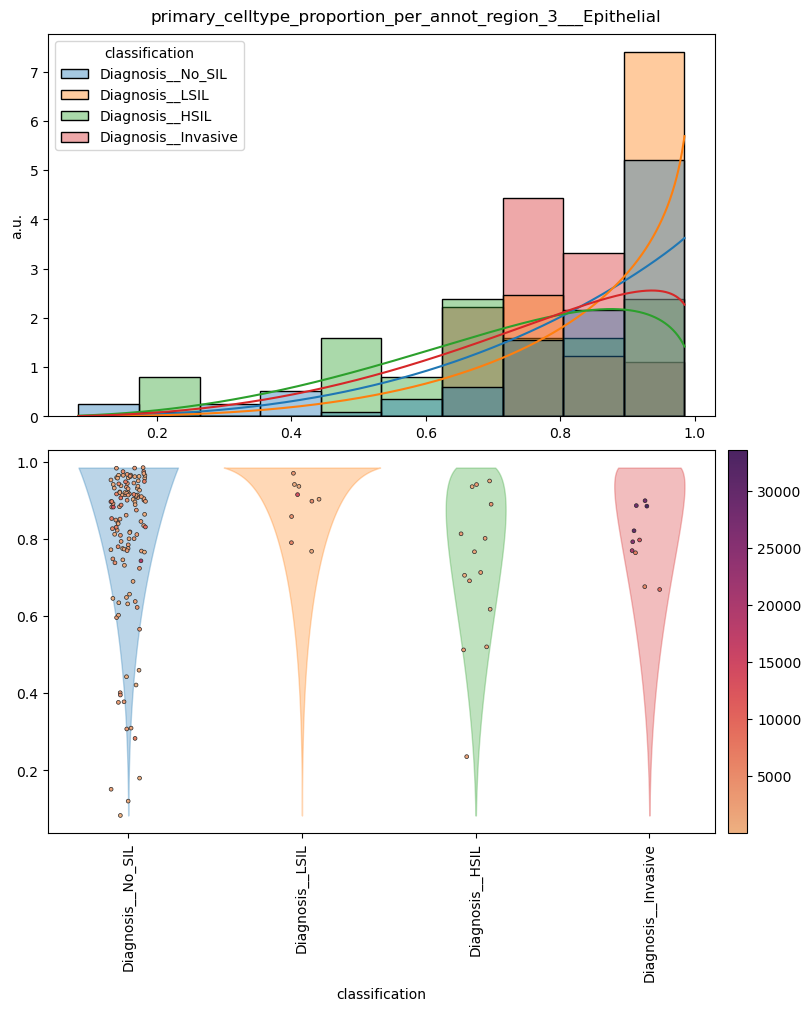

In [13]:
glms.plot_model(
    'primary_celltype_proportion_per_annot_region_3___Epithelial', #Which feature are we plotting
    fitted = True, # If true, use the fitted distribution of the means
    order = ['Diagnosis__No_SIL', 'Diagnosis__LSIL', 'Diagnosis__HSIL', 'Diagnosis__Invasive'] # From left->right, order of categories in the violin plot
)

Do the permutation testing for the likelihood ratio tests (ignore pandas warning about groupby)

In [14]:
# Optional step is to check whether to do inner or outer parallelism
# Depending on number of jobs/models/nodes, sometimes it is faster to run each permutation in parallel
# Other times it may be faster to run permutations in series but parallelize the model fitting
# Due to joblib limitations we cannot do nested parallelism
# These are very rough estimates

jobs_dict = glms.test_run(n_perm = 100)
print(jobs_dict)

Running test with inner parallelism


Running permutation tests: 100%|██████████| 1/1 [00:10<00:00, 10.26s/it]


Running test with outer parallelism


Calculating permutations: 100%|██████████| 47/47 [00:59<00:00,  1.26s/it]



Estimated time with inner parallelism: 17.12 min
Estimated time with outer parallelism: 2.97 min
{'n_jobs': 47, 'n_jobs_inner': 1}


In [15]:
import multiprocessing
n_jobs = int(multiprocessing.cpu_count())
ref_class = {'Diagnosis': 'No_SIL'}
stat_res = glms.run_stats_with_permutations(
    #ref_class = ref_class, # Optional: when making pairwise comparisons, use ref_class as reference class for all comparisons. Otherwise do pairwise comparisons for each value in comparisons
    n_permutations = 100, # number of permutations (null distribution will have <= n_permutations * n_features test stats). We're only doing 100 for brevity. Generally I'll do 1000
    fdr_group = 'feature_type', # Optional: When doing fdr correction, do corrections only within a single group
    **jobs_dict
)

Calculating permutations: 100%|██████████| 100/100 [01:51<00:00,  1.12s/it]
/common/lamt2/tutorials/regression_models/GLMCollection.py:965: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stat_df = stat_df.groupby(fdr_group, group_keys = False).apply(lambda g: calculate_empirical_fdr(g, perm_df[key], fdr_group, stat_col = 't-wald'), include_groups = True)
/common/lamt2/tutorials/regression_models/GLMCollection.py:965: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping col

The permutation test returns a dictionary of stat results: one for the LLR test and one for each pairwise comparison

If we designated a reference class, the key will be the information of the test class. Otherwise the keys for pairwise comparisons are named `{comparison}__{test_class}_vs_{ref_class}___{columns}__{fixed_values}`

In [16]:
list(stat_res.keys())

['Diagnosis__Invasive_vs_No_SIL___SCC_ADENO__SCC___P53__0___HR_HPV__0',
 'Diagnosis__Invasive_vs_HSIL___SCC_ADENO__SCC___P53__0___HR_HPV__0',
 'Diagnosis__Invasive_vs_LSIL___SCC_ADENO__SCC___P53__0___HR_HPV__0',
 'Diagnosis__No_SIL_vs_HSIL___SCC_ADENO__SCC___P53__0___HR_HPV__0',
 'Diagnosis__No_SIL_vs_LSIL___SCC_ADENO__SCC___P53__0___HR_HPV__0',
 'Diagnosis__HSIL_vs_LSIL___SCC_ADENO__SCC___P53__0___HR_HPV__0',
 'llr']

The 'llr' result contains a dataframe with the feature test stats/p-values and a 'perm_df' dataframe with all of the permutation results

The relevant columns are:
* p-nom: The nominal p-value, calculated from the tail of the null distribution
* fdr-q-val: The nominal p-value divided by the number of features with a greater or equal test statistic
* p-adj: The minimum fdr-q-value from all features with a lesser or equal test statistic (keeps p-value monotonic in test statistic)

In [17]:
stat_res['llr']['df'].head(5)

,stat,Celltype,Region,feature_type,p-nom,fdr-q-val,p-adj
primary_celltype_proportion_per_annot_region_2___B_plasma,7.597935,B_plasma,Stroma,primary_celltype_proportion,0.028873,0.086619,0.086619
primary_celltype_proportion_per_annot_region_3___B_plasma,1.914227,B_plasma,Epithelium,primary_celltype_proportion,0.395891,0.419179,0.419179
primary_celltype_proportion_per_annot_region_2___Epithelial,9.206835,Epithelial,Stroma,primary_celltype_proportion,0.013881,0.049972,0.049972
primary_celltype_proportion_per_annot_region_3___Epithelial,3.884950,Epithelial,Epithelium,primary_celltype_proportion,0.143809,0.172571,0.172571
primary_celltype_proportion_per_annot_region_2___Mast_cell,4.039843,Mast_cell,Stroma,primary_celltype_proportion,0.134370,0.186050,0.172571


In [18]:
stat_res['llr']['perm_df'].head(5)

,stat,Celltype,Region,feature_type,perm_iter
primary_celltype_proportion_per_annot_region_2___B_plasma,2.288309,B_plasma,Stroma,primary_celltype_proportion,0
primary_celltype_proportion_per_annot_region_3___B_plasma,0.304522,B_plasma,Epithelium,primary_celltype_proportion,0
primary_celltype_proportion_per_annot_region_2___Epithelial,4.281018,Epithelial,Stroma,primary_celltype_proportion,0
primary_celltype_proportion_per_annot_region_3___Epithelial,0.553029,Epithelial,Epithelium,primary_celltype_proportion,0
primary_celltype_proportion_per_annot_region_2___Mast_cell,7.441229,Mast_cell,Stroma,primary_celltype_proportion,0


Plot the difference in nominal p-value and fdr corrected q-value. Since we only have 20 permutations this will look a bit weird

Text(0, 0.5, 'FDR adjusted p-value')

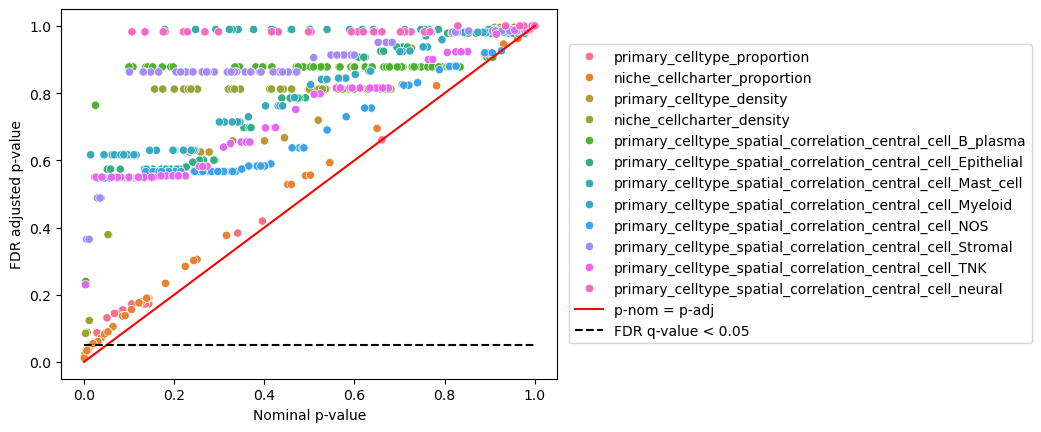

In [19]:
df = stat_res['llr']['df']
sns.scatterplot(x = 'p-nom', y = 'p-adj', data = df, hue = 'feature_type')
plt.plot([0, 1], [0, 1], 'r-', label = 'p-nom = p-adj')
plt.plot([0, 1], [0.05, 0.05], '--', c = 'black', label = 'FDR q-value < 0.05')
plt.legend(loc = 'center left', bbox_to_anchor = (1.01, 0.5))
plt.xlabel("Nominal p-value")
plt.ylabel("FDR adjusted p-value")

# After we run the statsmodels, we can plot the differences for each progression class

The plotting functions are very jank and have too many ad-hoc corrections. Adapt them at your own risk

Combine all stat_res dataframes to make the plot. This function takes all comparisons relative to the given reference class

In [20]:
res_df = get_progression_df(stat_res, ref_class)

# Plot one feature type at a time
feature = 'primary_celltype_proportion'
sub_res_df = res_df[res_df['feature_type'] == feature]

# Filter anova df to match the feature df
sub_llr_df = stat_res['llr']['df']
sub_llr_df = sub_llr_df[sub_llr_df['feature_type'] == feature]

Make the progression plot:

Each row is the comparison results for a given celltype/region. The values in the plot are the differences between the test category and the reference category. p-values on the right are the FDR q-values calculated by the pseudo-anova log-likelihood permutation tests (bold for <0.05). The columns are different stages in diagnosis

From the plot, you can see that Myeloid cell proportions in epithelial regions tends to increase from LSIL -> HSIL -> Invasive, and is significant with FDR q-value = 0.02

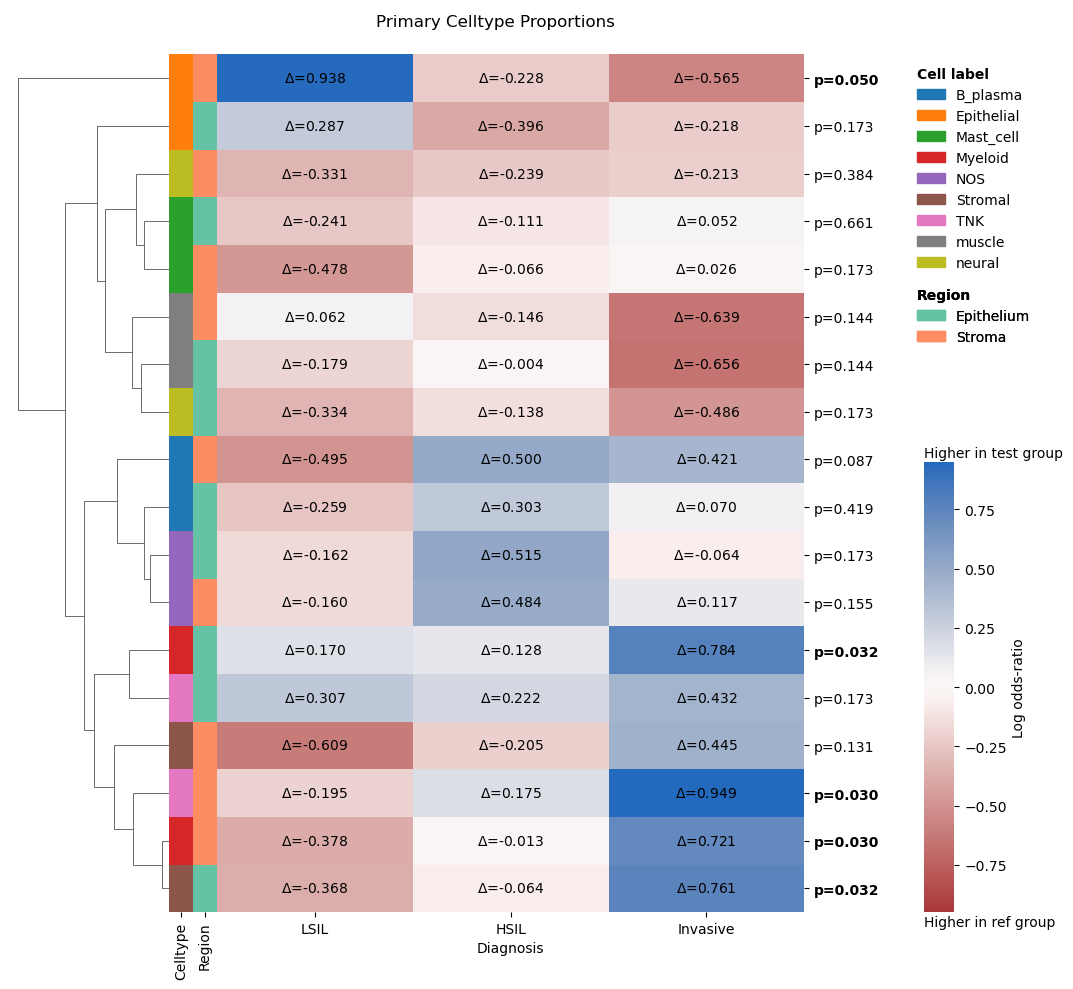

In [21]:
fig = plot_progression_heatmap(
    sub_res_df,                # Dataframe containing the stat results
    llr_df = sub_llr_df,   # Dataframe to label the categories p-values
    row_cluster = True,    # Cluster rows and plot the dendrogram
    index = ['Celltype', 'Region'],  # Index each row by unique celltype/region
    columns = ['Diagnosis'],          # Each diagnosis stage is its own column
    values = 'effect',               # Use the linear effect as the color value
    order = ['LSIL', 'HSIL', 'Invasive'], # Left to right order of columns
    ncols = 1, # Number of legend columns for the "Celltype" categories. (jank, ncol>1 only really works with niches)
    title = 'Primary Celltype Proportions',
    cbar_label = 'Log odds-ratio'      # Colorbar label. For proportions the logit link gives log odds-ratios
)

Plot one of the results to see if it makes sense

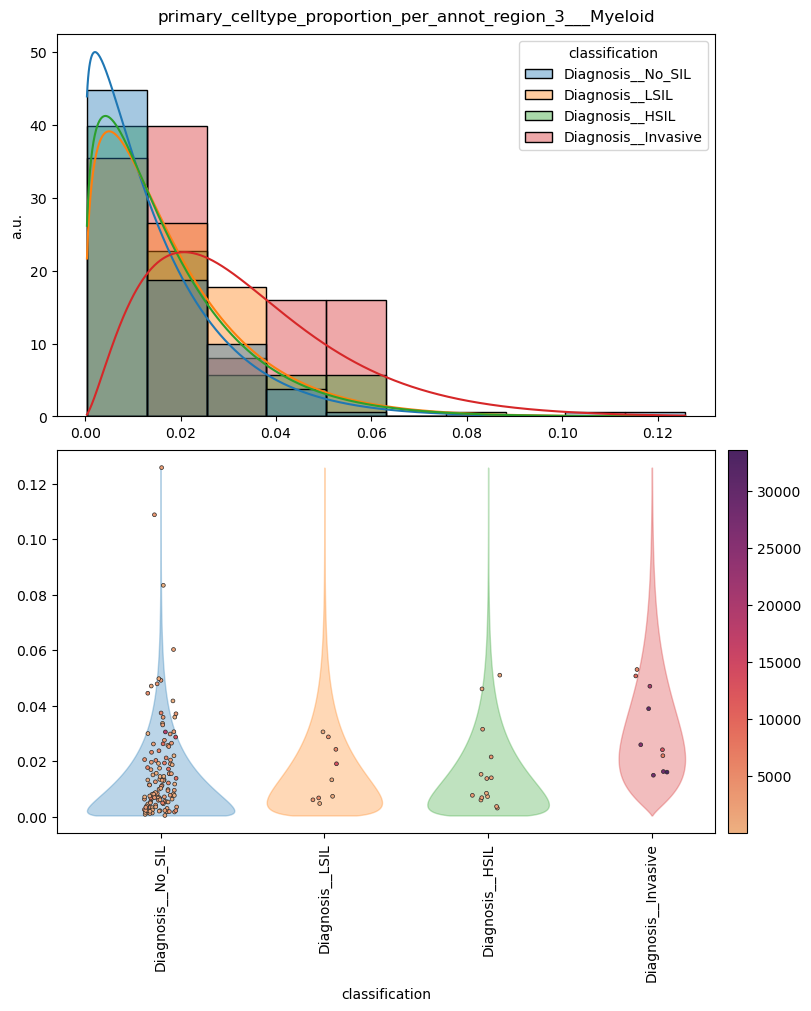

In [22]:
glms.plot_model(
    'primary_celltype_proportion_per_annot_region_3___Myeloid',
    fitted = True,
    order = ['Diagnosis__No_SIL', 'Diagnosis__LSIL', 'Diagnosis__HSIL', 'Diagnosis__Invasive'])

We can make the same plot for spatial correlations (fixing Epithelial as the central celltype)

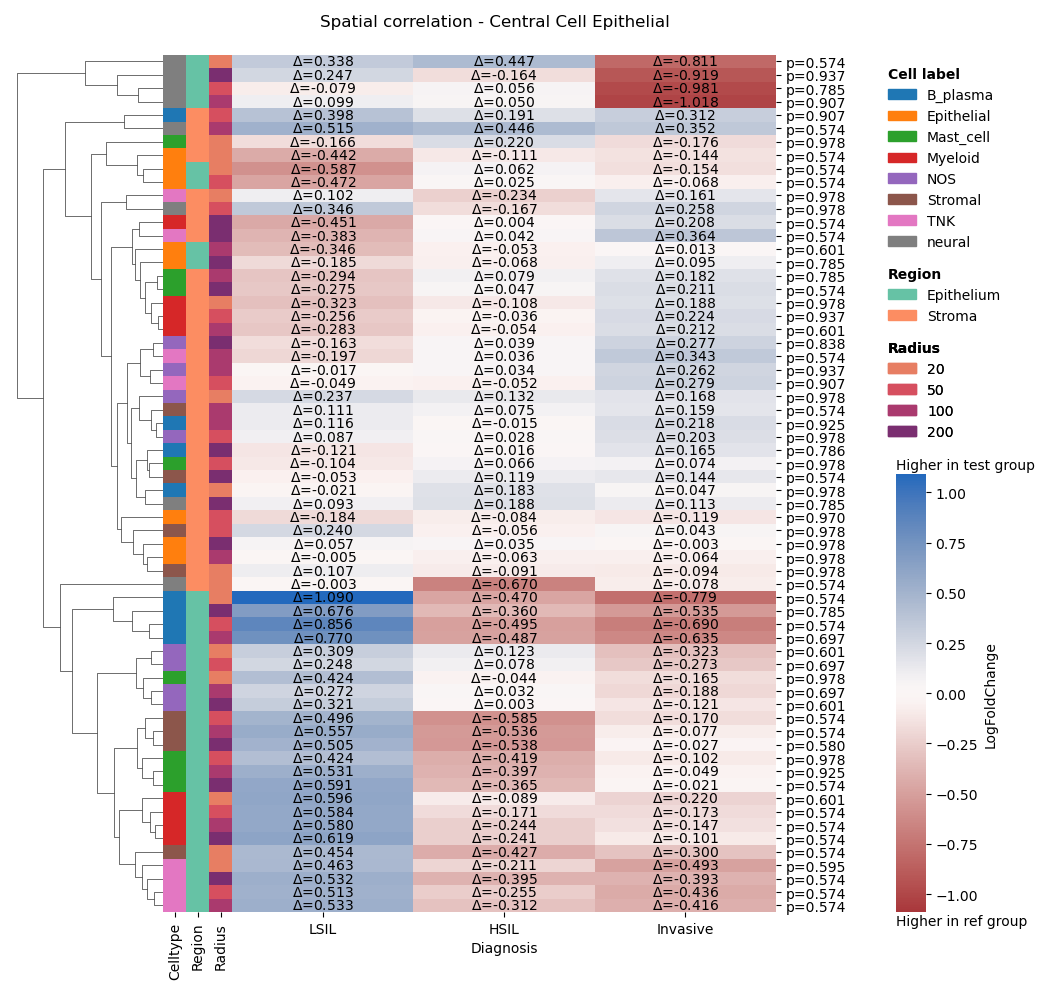

In [23]:
# select spatial correlations
feature = 'primary_celltype_spatial_correlation_central_cell_Epithelial'
sub_res_df = res_df[res_df['feature_type'] == feature].copy()
sub_res_df.head(5)

# Filter llr df to match the feature df
sub_llr_df = stat_res['llr']['df'].copy()
sub_llr_df = sub_llr_df[sub_llr_df['feature_type'] == feature].copy()

# We have to do some formatting, since we have spatial correlations for multiple radii
# Add a column for the radius
sub_res_df['Radius'] = sub_res_df['feature'].apply(lambda x: x.split('radius_')[1].split('_')[0]).astype(int)
sub_llr_df['Radius'] = sub_llr_df.index.to_series().apply(lambda x: x.split('radius_')[1].split('_')[0]).astype(int)

fig = plot_progression_heatmap(
    sub_res_df,                
    llr_df = sub_llr_df,
    row_cluster = True,
    index = ['Celltype', 'Region', 'Radius'],  #We've added radius to the list of indices
    columns = ['Diagnosis'],          
    values = 'effect',           
    order = ['LSIL', 'HSIL', 'Invasive'], 
    ncols = 1, 
    title = 'Spatial correlation - Central Cell Epithelial',
    cbar_label = 'LogFoldChange'      # Colorbar label is different since log link gives logfoldchanges
)

### Plotting pairwise comparisons

Lets look at the specific differences between Invasive and No_SIL

In [24]:
# See the GLMCollection.get_stats() to see more about the outputs
stat_res['Diagnosis__Invasive_vs_No_SIL___SCC_ADENO__SCC___P53__0___HR_HPV__0']['df'].head(5)

,t-wald,p-wald,effect,effectSE,Celltype,Region,feature_type,p-nom,fdr-q-val,p-adj
primary_celltype_proportion_per_annot_region_2___B_plasma,1.879492,0.170392,0.420731,0.306891,B_plasma,Stroma,primary_celltype_proportion,0.106052,0.173540,0.173540
primary_celltype_proportion_per_annot_region_3___B_plasma,0.047006,0.828358,0.070084,0.323254,B_plasma,Epithelium,primary_celltype_proportion,0.777346,0.932815,0.847176
primary_celltype_proportion_per_annot_region_2___Epithelial,2.430124,0.119023,-0.565354,0.362666,Epithelial,Stroma,primary_celltype_proportion,0.074958,0.149917,0.149917
primary_celltype_proportion_per_annot_region_3___Epithelial,0.553386,0.456938,-0.217569,0.292472,Epithelial,Epithelium,primary_celltype_proportion,0.359800,0.539700,0.535087
primary_celltype_proportion_per_annot_region_2___Mast_cell,0.013429,0.907746,0.025509,0.220125,Mast_cell,Stroma,primary_celltype_proportion,0.875625,0.875625,0.875625


Make a dotplot showing the pairwise comparisons for each feature for a given type

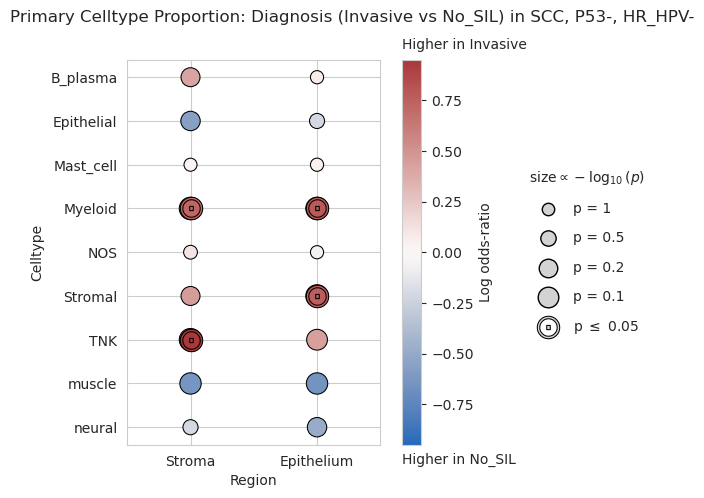

In [25]:
stat_df = stat_res['Diagnosis__Invasive_vs_No_SIL___SCC_ADENO__SCC___P53__0___HR_HPV__0']['df']
fig = make_dotplot(
    stat_df,
    feature_type = 'primary_celltype_proportion',  # Which feature we want to plot
    x_col = 'Region', # col to split features into columns
    y_col = 'Celltype', # col to split features into rows
    hue_col = 'effect', # col for coloring each dot
    pval_col = 'p-adj', # col to size the dots
    cbar_label = 'Log odds-ratio', # Label for colorbar
    test_group = 'Invasive', # Test group (for naming on colorbar)
    ref_group = 'No_SIL', # Ref group (for colorbar naming)
    title = 'Primary Celltype Proportion: Diagnosis (Invasive vs No_SIL) in SCC, P53-, HR_HPV-'
)